# **Data Importations**

## **Loading Libraries**

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
data=pd.read_csv("GSSsubset.csv")
data.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,BACHELOR,60967.50,DIVORCED,53,72,190,60
1,2,FEMALE,BACHELOR,60967.50,MARRIED,26,60,97,40
2,4,FEMALE,BACHELOR,10161.25,MARRIED,56,68,160,20
3,14,FEMALE,HIGH SCHOOL,17551.25,MARRIED,40,65,156,37
4,16,MALE,HIGH SCHOOL,17551.25,MARRIED,56,66,210,6


## **Examination of Data Set**

In [9]:
data.tail(10)

,id,sex,degree,income,marital,age,height,weight,hrswrk
984,2523,MALE,BACHELOR,24017.50,MARRIED,54,72,195,40
985,2524,MALE,BACHELOR,33255.00,MARRIED,49,70,195,40
986,2525,FEMALE,BACHELOR,33255.00,MARRIED,53,64,150,40
987,2526,MALE,BACHELOR,40645.00,MARRIED,52,72,200,50
988,2530,MALE,HIGH SCHOOL,33255.00,MARRIED,62,71,215,48
989,2531,MALE,HIGH SCHOOL,1478.00,NEVER MARRIED,40,71,230,48
990,2535,MALE,HIGH SCHOOL,33255.00,DIVORCED,56,72,195,46
991,2536,MALE,HIGH SCHOOL,8313.75,NEVER MARRIED,24,68,145,40
992,2537,MALE,HIGH SCHOOL,27712.50,NEVER MARRIED,27,68,180,40
993,2538,FEMALE,HIGH SCHOOL,15703.75,WIDOWED,71,63,140,48


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       994 non-null    int64  
 1   sex      994 non-null    object 
 2   degree   994 non-null    object 
 3   income   994 non-null    float64
 4   marital  994 non-null    object 
 5   age      994 non-null    int64  
 6   height   994 non-null    int64  
 7   weight   994 non-null    int64  
 8   hrswrk   994 non-null    int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 70.0+ KB


## **Data Cleaning and preprocessing**
### **Handling Missing Values**
#### **Check For Missing Values in Every Column**

In [12]:
miss_value=data.isnull().sum()
miss_value

id         0
sex        0
degree     0
income     0
marital    0
age        0
height     0
weight     0
hrswrk     0
dtype: int64

#### **Remove rows with missing values**

In [13]:
data.dropna(inplace=True)
miss_value=data.isnull().sum()
miss_value

id         0
sex        0
degree     0
income     0
marital    0
age        0
height     0
weight     0
hrswrk     0
dtype: int64

#### **Identification of Outliers Using BoxPlots**

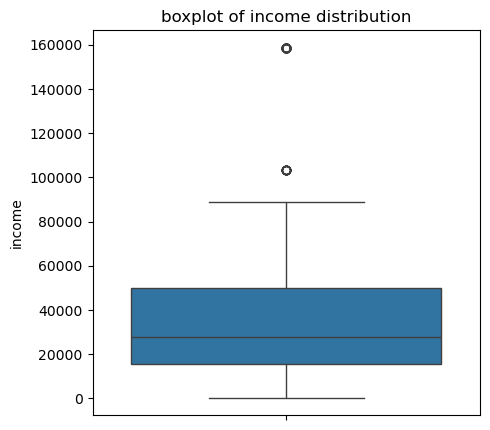

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5,5))
sns.boxplot(data=data,y="income")
plt.title("boxplot of income distribution")
plt.ylabel("income")
plt.show()

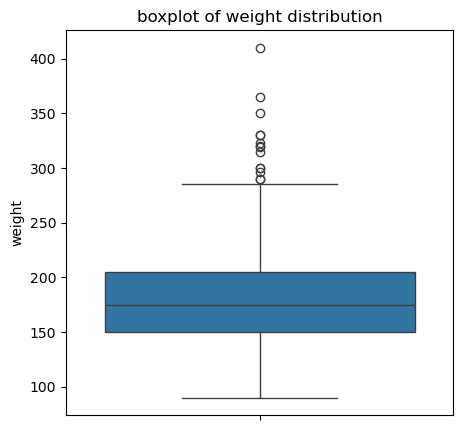

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5,5))
sns.boxplot(data=data,y="weight")
plt.title("boxplot of weight distribution")
plt.ylabel("weight")
plt.show()

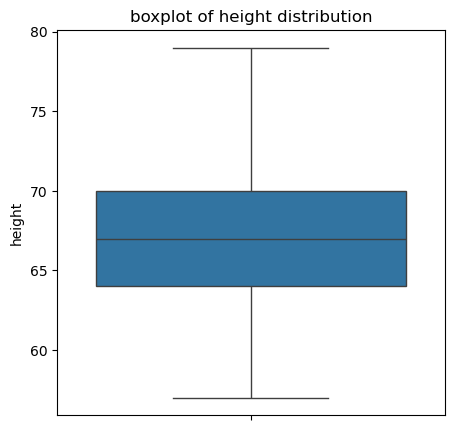

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5,5))
sns.boxplot(data=data,y="height")
plt.title("boxplot of height distribution")
plt.ylabel("height")
plt.show()

### **BoxPlot of all Numerical Variables**

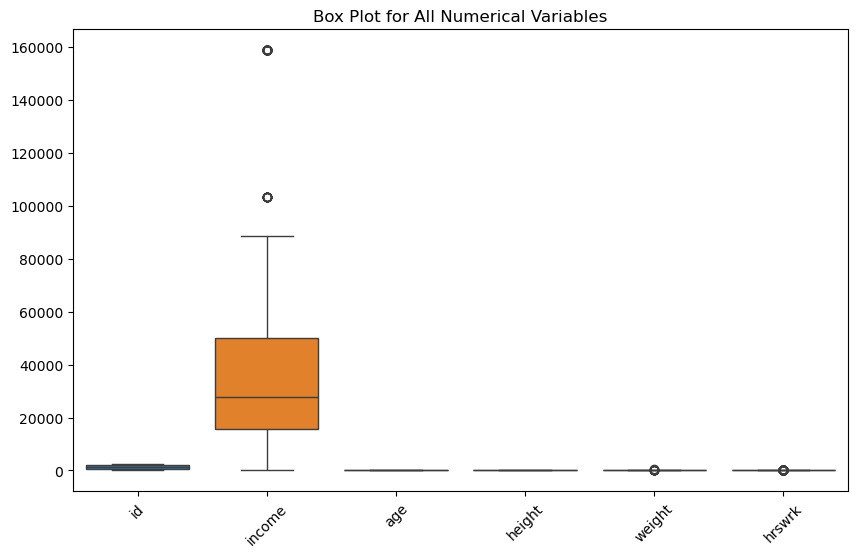

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)

plt.xticks(rotation=45)
plt.title("Box Plot for All Numerical Variables")
plt.show()

#### **Remove Outliers**
#### **1.1.5 Inter-Quartile Rule**

In [19]:
Q1 = data["income"].quantile(0.25)
Q3 = data["income"].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data["income"] >=lower_bound) & (data["income"] <=upper_bound)]

In [23]:
Q1 = data["income"].quantile(0.25)
Q3 = data["income"].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data["income"] >=lower_bound) & (data["income"] <=upper_bound)]
data

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,BACHELOR,60967.50,DIVORCED,53,72,190,60
1,2,FEMALE,BACHELOR,60967.50,MARRIED,26,60,97,40
2,4,FEMALE,BACHELOR,10161.25,MARRIED,56,68,160,20
3,14,FEMALE,HIGH SCHOOL,17551.25,MARRIED,40,65,156,37
4,16,MALE,HIGH SCHOOL,17551.25,MARRIED,56,66,210,6
...,...,...,...,...,...,...,...,...,...
989,2531,MALE,HIGH SCHOOL,1478.00,NEVER MARRIED,40,71,230,48
990,2535,MALE,HIGH SCHOOL,33255.00,DIVORCED,56,72,195,46
991,2536,MALE,HIGH SCHOOL,8313.75,NEVER MARRIED,24,68,145,40
992,2537,MALE,HIGH SCHOOL,27712.50,NEVER MARRIED,27,68,180,40


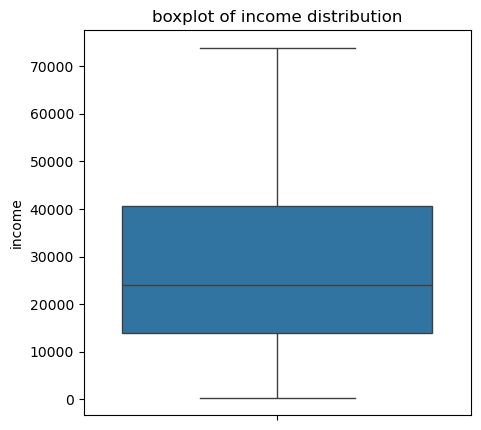

In [21]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data,y="income")
plt.title("boxplot of income distribution")
plt.ylabel("income")
plt.show()

### **Remove the Outliers**

In [ ]:
Q1 = data["income"].quantile(0.25)
Q3 = data["income"].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data["income"] >=lower_bound) & (data["income"] <=upper_bound)]

## **Summary Statistics**

In [27]:
summary_statistics=data.describe()
summary_statistics

,id,income,age,height,weight,hrswrk
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,1297.983462,28125.794101,43.918412,67.206174,180.155458,41.750827
std,728.457647,18434.522770,13.160663,4.030026,41.859287,13.948490
min,1.000000,369.500000,19.000000,57.000000,90.000000,1.000000
25%,693.000000,13856.250000,33.000000,64.000000,150.000000,36.500000
50%,1288.000000,24017.500000,43.000000,67.000000,175.000000,40.000000
75%,1932.500000,40645.000000,54.000000,70.000000,202.500000,50.000000
max,2538.000000,73900.000000,79.000000,78.000000,410.000000,89.000000


In [28]:
summary_statistics=data.drop(columns=["id"]).describe()
summary_statistics

,income,age,height,weight,hrswrk
count,907.000000,907.000000,907.000000,907.000000,907.000000
mean,28125.794101,43.918412,67.206174,180.155458,41.750827
std,18434.522770,13.160663,4.030026,41.859287,13.948490
min,369.500000,19.000000,57.000000,90.000000,1.000000
25%,13856.250000,33.000000,64.000000,150.000000,36.500000
50%,24017.500000,43.000000,67.000000,175.000000,40.000000
75%,40645.000000,54.000000,70.000000,202.500000,50.000000
max,73900.000000,79.000000,78.000000,410.000000,89.000000


### **Summary Statistics for Categorical Varibles**

In [30]:
categorical_summary=data.describe(include=["O"])
categorical_summary

,sex,degree,marital
count,907,907,907
unique,2,5,5
top,FEMALE,HIGH SCHOOL,MARRIED
freq,469,473,421


## Data Visualization

### Histogram

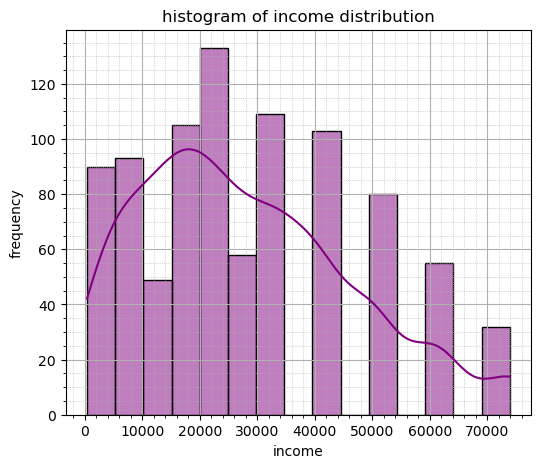

In [34]:
plt.figure(figsize=(6,5))
sns.histplot(data=data,x="income",bins=15,kde=True,color="purple")
plt.xlabel("income")
plt.ylabel("frequency")
plt.title("histogram of income distribution")
plt.minorticks_on()

plt.grid(which='minor', linestyle=':', linewidth=0.5)
plt.grid(True)
plt.show()

### BoxPlot of income Across Degree

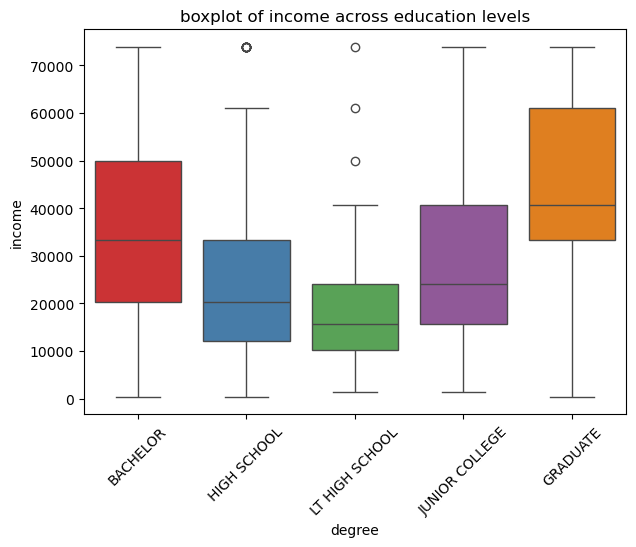

In [39]:
plt.figure(figsize=(7,5))
sns.boxplot(data=data,x="degree",y="income",hue="degree",palette="Set1")
plt.xticks(rotation=45)
plt.xlabel("degree")
plt.ylabel("income")
plt.title("boxplot of income across education levels")
plt.show()